In [1]:
!pip install --upgrade pip -q

!pip install -q s3fs xgboost pyarrow

!pip install -q "scikit-learn==1.2.2" "imbalanced-learn==0.10.1"

!pip install -q "keras-tuner==1.4.6"

In [2]:
import sagemaker
import boto3
import os
import tarfile
import joblib
import tensorflow as tf
import xgboost as xgb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# --- Variáveis Chave ---
s3_uri_brf = "s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/brf-models/brf-ons-risk-fixed-20251020-212249/output/model.tar.gz"
s3_uri_xgb = "s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/xgboost-models/xgb-ons-risk-pos-2010-20251021-000605/output/model.tar.gz"
s3_uri_lstm = "s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/lstm-models/lstm-ons-risk-pos-2010-20251021-003449/output/model.tar.gz"

# --- CAMINHO DOS DADOS ---
s3_data_prefix_path = "s3://ons-risk-prediction-data-674650987717/export/"
# -----------------------------------

# Nomes de diretório para organizar os modelos localmente
MODEL_DIR_BRF = "./model_brf/"
MODEL_DIR_XGB = "./model_xgb/"
MODEL_DIR_LSTM = "./model_lstm/"

print(f"Caminho BRF: {s3_uri_brf}")
print(f"Caminho XGB: {s3_uri_xgb}")
print(f"Caminho LSTM: {s3_uri_lstm}")
print(f"Lendo TODOS os dados de: {s3_data_prefix_path}")

/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


2025-10-21 01:35:46.175142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-21 01:35:46.209671: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-21 01:35:46.209717: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-21 01:35:46.226489: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-21 01:35:48.230604: W tensorflow/com

Caminho BRF: s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/brf-models/brf-ons-risk-fixed-20251020-212249/output/model.tar.gz
Caminho XGB: s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/xgboost-models/xgb-ons-risk-pos-2010-20251021-000605/output/model.tar.gz
Caminho LSTM: s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/lstm-models/lstm-ons-risk-pos-2010-20251021-003449/output/model.tar.gz
Lendo TODOS os dados de: s3://ons-risk-prediction-data-674650987717/export/


In [3]:
def download_and_extract_model(s3_uri, local_dir):
    """Baixa um model.tar.gz do S3 e o extrai para um diretório local."""
    if not os.path.exists(local_dir):
        os.makedirs(local_dir)
    
    local_tar_path = os.path.join(local_dir, "model.tar.gz")
    
    # Extrai bucket e key do S3 URI
    bucket = s3_uri.split('/')[2]
    key = '/'.join(s3_uri.split('/')[3:])
    
    # Baixa
    print(f"Baixando {s3_uri} para {local_tar_path}...")
    s3_client = boto3.client('s3')
    try:
        s3_client.download_file(bucket, key, local_tar_path)
    except Exception as e:
        print(f"Erro ao baixar {s3_uri}: {e}")
        return

    # Extrai
    print(f"Extraindo {local_tar_path}...")
    with tarfile.open(local_tar_path, 'r:gz') as tar:
        tar.extractall(path=local_dir)
    print(f"Modelo extraído em: {local_dir}")

# Executa a função para cada modelo
download_and_extract_model(s3_uri_brf, MODEL_DIR_BRF)
download_and_extract_model(s3_uri_xgb, MODEL_DIR_XGB)
download_and_extract_model(s3_uri_lstm, MODEL_DIR_LSTM)

Baixando s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/brf-models/brf-ons-risk-fixed-20251020-212249/output/model.tar.gz para ./model_brf/model.tar.gz...
Extraindo ./model_brf/model.tar.gz...
Modelo extraído em: ./model_brf/
Baixando s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/xgboost-models/xgb-ons-risk-pos-2010-20251021-000605/output/model.tar.gz para ./model_xgb/model.tar.gz...
Extraindo ./model_xgb/model.tar.gz...
Modelo extraído em: ./model_xgb/
Baixando s3://sagemaker-us-east-1-674650987717/ons-risk-prediction/lstm-models/lstm-ons-risk-pos-2010-20251021-003449/output/model.tar.gz para ./model_lstm/model.tar.gz...
Extraindo ./model_lstm/model.tar.gz...
Modelo extraído em: ./model_lstm/


In [7]:
import os
import joblib
import tensorflow as tf
import xgboost as xgb
import numpy as np

# --- DEBUG: Listar arquivos ---
print("--- Arquivos extraídos para o BRF: ---")
!ls -R ./model_brf/
print("--- Arquivos extraídos para o XGB: ---")
!ls -R ./model_xgb/
print("--- Arquivos extraídos para o LSTM: ---")
!ls -R ./model_lstm/
print("---------------------------------")

# Definir variáveis fora do try
model_brf, scaler_brf, feature_names_brf, target_mapping = None, None, None, None
model_xgb, scaler_xgb, feature_names_xgb, risk_thresholds = None, None, None, None # Adicionado risk_thresholds
model_lstm, scaler_lstm, feature_names_lstm = None, None, None

# --- Carregar Artefatos 1: BRF ---
print("\n--- Carregando BRF ---")
try:
    path_brf = os.path.join(MODEL_DIR_BRF, 'brf-model.joblib')
    path_scaler_brf = os.path.join(MODEL_DIR_BRF, 'scaler_brf.joblib')
    path_features_brf = os.path.join(MODEL_DIR_BRF, 'feature_names.joblib')
    path_target_map_brf = os.path.join(MODEL_DIR_BRF, 'target_mapping.joblib')

    model_brf = joblib.load(path_brf)
    scaler_brf = joblib.load(path_scaler_brf)
    feature_names_brf = joblib.load(path_features_brf) 
    target_mapping = joblib.load(path_target_map_brf)
    print(f"✓ Modelo BRF carregado com {len(feature_names_brf)} features.")
except Exception as e:
     print(f"!!! ERRO AO CARREGAR BRF: {e}")

# --- Carregar Artefatos 2: XGBoost ---
print("\n--- Carregando XGBoost ---")
try:
    path_xgb_model = os.path.join(MODEL_DIR_XGB, 'xgboost-model.json') 
    path_scaler_xgb = os.path.join(MODEL_DIR_XGB, 'scaler_xgb.joblib')
    path_features_xgb = os.path.join(MODEL_DIR_XGB, 'feature_names_xgb.joblib') 
    path_thresholds_xgb = os.path.join(MODEL_DIR_XGB, 'risk_thresholds.joblib') # Caminho para thresholds

    model_xgb = xgb.Booster()
    model_xgb.load_model(path_xgb_model)
    scaler_xgb = joblib.load(path_scaler_xgb)
    feature_names_xgb = joblib.load(path_features_xgb) 
    risk_thresholds = joblib.load(path_thresholds_xgb) # Carregar thresholds
    print(f"✓ Modelo XGBoost carregado com {len(feature_names_xgb)} features.")
    print(f"✓ Thresholds carregados: q1={risk_thresholds.get('q1', 'N/A')}, q2={risk_thresholds.get('q2', 'N/A')}")
except Exception as e:
    print(f"!!! ERRO AO CARREGAR XGBoost: {e}")

# --- Carregar Artefatos 3: LSTM ---
print("\n--- Carregando LSTM ---")
try:
    path_lstm_model = os.path.join(MODEL_DIR_LSTM, 'lstm_model_pos_2010.h5') 
    path_scaler_lstm = os.path.join(MODEL_DIR_LSTM, 'scaler_lstm_pos_2010.joblib')
    path_features_lstm = os.path.join(MODEL_DIR_LSTM, 'feature_names_lstm.joblib')

    model_lstm = tf.keras.models.load_model(path_lstm_model) 
    scaler_lstm = joblib.load(path_scaler_lstm) 
    feature_names_lstm = joblib.load(path_features_lstm) 
    print(f"✓ Modelo LSTM carregado com {len(feature_names_lstm)} features.")
except FileNotFoundError as e:
    print(f"!!! ERRO CRÍTICO ao carregar LSTM: Arquivo não encontrado - {e}. Verifique o retreino.")
except Exception as e:
    print(f"!!! ERRO AO CARREGAR LSTM: {e}")

print("\n--- Célula 4 Concluída ---")
# Verificações finais
if target_mapping is None: print("!!! ATENÇÃO: 'target_mapping' não carregado.")
if risk_thresholds is None: print("!!! ATENÇÃO: 'risk_thresholds' não carregado.")
if feature_names_xgb is None: print("!!! ATENÇÃO: 'feature_names_xgb' não carregado.")
if feature_names_lstm is None: print("!!! ATENÇÃO: 'feature_names_lstm' não carregado.")

--- Arquivos extraídos para o BRF: ---
./model_brf/:
brf-model.joblib      model.tar.gz	 target_mapping.joblib
feature_names.joblib  scaler_brf.joblib
--- Arquivos extraídos para o XGB: ---
./model_xgb/:
feature_names_xgb.joblib  risk_thresholds.joblib  xgboost-model.json
model.tar.gz		  scaler_xgb.joblib
--- Arquivos extraídos para o LSTM: ---
./model_lstm/:
feature_names_lstm.joblib  model_metadata.joblib  risk_thresholds.joblib
lstm_model_pos_2010.h5	   model.tar.gz		  scaler_lstm_pos_2010.joblib
---------------------------------

--- Carregando BRF ---
✓ Modelo BRF carregado com 23 features.

--- Carregando XGBoost ---


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator StandardScaler from version 0.24.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✓ Modelo XGBoost carregado com 22 features.
✓ Thresholds carregados: q1=16.851724999999963, q2=136.20137499999984

--- Carregando LSTM ---
✓ Modelo LSTM carregado com 22 features.

--- Célula 4 Concluída ---


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Observação importante

Em algum momento do pipeline de dados em nuvem, na geração dos targets, foi usada uma forma diferente de divisão. Dado isto, há mais amostras de alto e médio, diferente do treinamento local.

Carregando e concatenando todos os arquivos de s3://ons-risk-prediction-data-674650987717/export/...
Total de dados: 5794, Usando 1159 amostras para teste.
Variável target '_COL_28' (contínua) separada.
Discretizando y_test (contínuo) em classes 0, 1, 2...
y_test discretizado. Distribuição: {0: 364, 1: 302, 2: 493}
Processando BRF...
✓ Predição BRF completa. Shape: (1159, 3)
Processando XGBoost...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✓ Predição XGBoost completa. Shape: (1159, 3)
Processando LSTM...
Shape das sequências de teste LSTM: (1146, 14, 22)
36/36 [==============================] - 3s 13ms/step
✓ Predição LSTM completa. Shape: (1146, 3)
✓ Target 'y_test' (discreto) alinhado para (1146,).

Calculando média do ensemble...
Alinhando predições para 1146 amostras.

--- Resultados Finais do Modelo Ensemble ---
              precision    recall  f1-score   support

       baixo       0.99      1.00      1.00       364
       medio       1.00      0.99      0.99       289
        alto       1.00      1.00      1.00       493

    accuracy                           1.00      1146
   macro avg       1.00      1.00      1.00      1146
weighted avg       1.00      1.00      1.00      1146



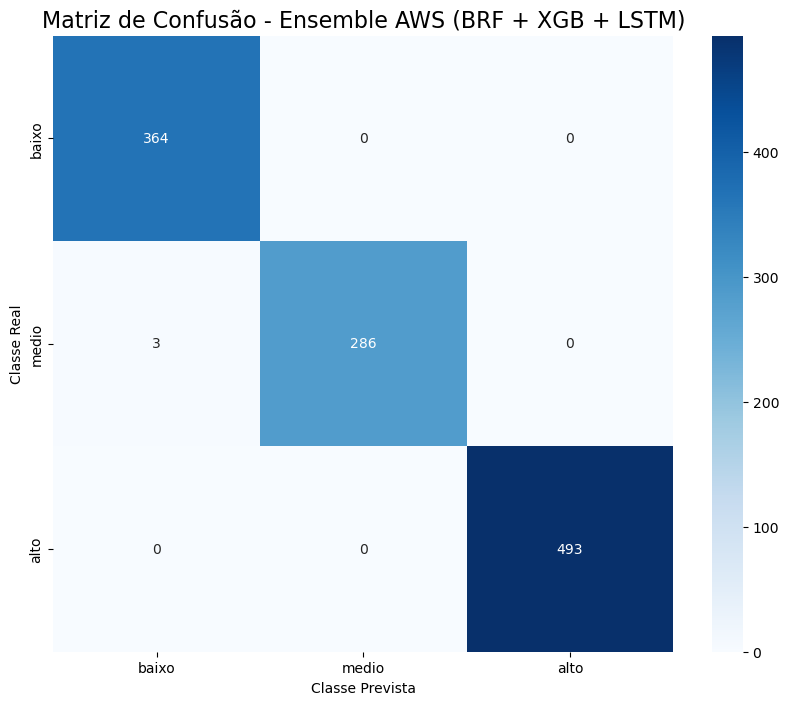

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# --- 1. CONFIGURAÇÃO ---
TARGET_COLUMN = '_COL_28' # Alvo

# Verificar se target_mapping carregou
if 'target_mapping' not in locals() or target_mapping is None:
    print("ERRO FATAL: target_mapping não carregado. Usando labels padrão.")
    mapeamento_risco_labels = ["Classe 0", "Classe 1", "Classe 2"] 
else:
     mapeamento_risco_labels = list(target_mapping.keys()) 

# Verificar se risk_thresholds carregou
if 'risk_thresholds' not in locals() or risk_thresholds is None:
     print("ERRO FATAL: risk_thresholds não carregados. Não é possível discretizar y_test.")
     # Parar ou definir valores padrão se apropriado
     # Exemplo: sys.exit("Erro: Thresholds não carregados.")

nome_cenario = "Ensemble AWS (BRF + XGB + LSTM)"
# --- FIM DA CONFIGURAÇÃO ---


# --- 2. Carregar Dados de Teste ---
print(f"Carregando e concatenando todos os arquivos de {s3_data_prefix_path}...")
df_completo = pd.read_parquet(s3_data_prefix_path)

# --- 3. Separação e ENCODING de Teste ---
test_size_ratio = 0.2
split_index = int(len(df_completo) * (1 - test_size_ratio))
df_teste = df_completo[split_index:].copy()
y_test_continuous = df_teste[TARGET_COLUMN] # y_test original (contínuo)
print(f"Total de dados: {len(df_completo)}, Usando {len(df_teste)} amostras para teste.")
print(f"Variável target '{TARGET_COLUMN}' (contínua) separada.")

# --- CORREÇÃO: Discretizar y_test usando os thresholds carregados ---
print("Discretizando y_test (contínuo) em classes 0, 1, 2...")
q1 = risk_thresholds['q1']
q2 = risk_thresholds['q2']
y_test_encoded = pd.Series(index=y_test_continuous.index, dtype=int)
y_test_encoded[y_test_continuous <= q1] = 0  # Baixo
y_test_encoded[(y_test_continuous > q1) & (y_test_continuous <= q2)] = 1  # Médio
y_test_encoded[y_test_continuous > q2] = 2  # Alto
y_test_encoded = y_test_encoded.astype(int)
print(f"y_test discretizado. Distribuição: {y_test_encoded.value_counts().sort_index().to_dict()}")
# ------------------------------------------------------------------


# --- 4. Pré-processamento e Predição ---
# Calcular mediana (baseada nas 23 features do BRF - apenas para fillna)
test_median_brf_fill = df_teste[feature_names_brf].median()

# --- BRF ---
if feature_names_brf is None or scaler_brf is None or model_brf is None:
    print("!!! ERRO: Artefatos do BRF não carregados. Pulando predição.")
    proba_brf = np.zeros((len(df_teste), 3)) 
else:
    print("Processando BRF...")
    X_test_brf_raw = df_teste[feature_names_brf] 
    X_test_brf_filled = X_test_brf_raw.fillna(test_median_brf_fill).fillna(0)
    X_test_brf = scaler_brf.transform(X_test_brf_filled)
    proba_brf = model_brf.predict_proba(X_test_brf)
    print(f"✓ Predição BRF completa. Shape: {proba_brf.shape}")

# --- XGBoost ---
if feature_names_xgb is None or scaler_xgb is None or model_xgb is None:
     print("!!! ERRO: Artefatos do XGBoost não carregados. Pulando predição.")
     proba_xgb = np.zeros_like(proba_brf) 
else:
    print("Processando XGBoost...")
    X_test_xgb_raw = df_teste[feature_names_xgb] 
    test_median_xgb = X_test_xgb_raw.median()
    X_test_xgb_filled = X_test_xgb_raw.fillna(test_median_xgb).fillna(0)
    X_test_xgb = scaler_xgb.transform(X_test_xgb_filled) 
    dmatrix_xgb = xgb.DMatrix(X_test_xgb) 
    proba_xgb = model_xgb.predict(dmatrix_xgb)
    print(f"✓ Predição XGBoost completa. Shape: {proba_xgb.shape}") 

# --- LSTM ---
if feature_names_lstm is None or scaler_lstm is None or model_lstm is None: 
    print("!!! ERRO: Artefatos do LSTM não carregados. Pulando predição.")
    proba_lstm = np.zeros_like(proba_brf) 
    # Usar y_test_encoded original se LSTM falhar (sem pular time_steps)
    y_test_seq = y_test_encoded.values 
    n_preds = len(proba_brf) 
else:
    print("Processando LSTM...")
    X_test_lstm_raw = df_teste[feature_names_lstm] 
    test_median_lstm = X_test_lstm_raw.median()
    X_test_lstm_filled = X_test_lstm_raw.fillna(test_median_lstm).fillna(0)
    X_test_lstm = scaler_lstm.transform(X_test_lstm_filled.values) 
    
    time_steps = 14 
    Xs_lstm = []
    for i in range(len(X_test_lstm) - time_steps + 1): 
        Xs_lstm.append(X_test_lstm[i:(i + time_steps)])
    X_test_lstm_seq = np.array(Xs_lstm)
    print(f"Shape das sequências de teste LSTM: {X_test_lstm_seq.shape}") 
    
    proba_lstm = model_lstm.predict(X_test_lstm_seq)
    
    # Alinhar y_test_encoded com a saída da predição LSTM
    # Pegar os últimos N valores de y_test_encoded
    y_test_seq = y_test_encoded.values[-len(proba_lstm):] # <<< USA O y_test_encoded
    n_preds = len(proba_lstm) 
    print(f"✓ Predição LSTM completa. Shape: {proba_lstm.shape}") 
    print(f"✓ Target 'y_test' (discreto) alinhado para {y_test_seq.shape}.")


# --- 5. Lógica do Ensemble ---
print("\nCalculando média do ensemble...")

if ('proba_brf' not in locals() or 'proba_xgb' not in locals() or 'proba_lstm' not in locals() or 
    len(proba_xgb.shape) != 2 or proba_xgb.shape[1] != 3 or 
    feature_names_brf is None or feature_names_xgb is None or feature_names_lstm is None):
    print(f"!!! ERRO CRÍTICO: Um ou mais modelos/artefatos não carregaram ou XGBoost tem shape errado.")
    print("!!! O ensemble não pode ser calculado.")
elif proba_lstm.shape[0] == 0 and model_lstm is not None: # Checa se LSTM rodou mas não gerou predições
     print("!!! ERRO CRÍTICO: LSTM não gerou predições (talvez dados de teste insuficientes para time_steps).")
     print("!!! O ensemble não pode ser calculado.")
else:
    # Alinhar predições ao tamanho da saída do LSTM (ou tamanho completo se LSTM falhou)
    proba_brf_aligned = proba_brf[-n_preds:]
    proba_xgb_aligned = proba_xgb[-n_preds:]
    # Se LSTM falhou, proba_lstm é zeros, n_preds é len(proba_brf), então está alinhado
    
    print(f"Alinhando predições para {n_preds} amostras.")
    
    # Calcular Média (Se LSTM falhou, adiciona zeros, o que está ok para média)
    y_pred_proba_ensemble = (proba_brf_aligned + proba_lstm[-n_preds:] + proba_xgb_aligned) / 3.0
    y_pred_ensemble = np.argmax(y_pred_proba_ensemble, axis=1)

    # --- 6. Visualização dos Resultados ---
    print(f"\n--- Resultados Finais do Modelo Ensemble ---")
    # Agora y_test_seq (discreto) e y_pred_ensemble (discreto) devem ser compatíveis
    print(classification_report(
        y_test_seq, 
        y_pred_ensemble, 
        target_names=mapeamento_risco_labels, 
        zero_division=0
    ))

    cm_ensemble = confusion_matrix(y_test_seq, y_pred_ensemble)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_ensemble, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=mapeamento_risco_labels,
        yticklabels=mapeamento_risco_labels
    )
    plt.title(f'Matriz de Confusão - {nome_cenario}', fontsize=16)
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.show()